This file will try to get a model which attempts to predict customer churn to a high degree (hopefully close to 90%). The only issue is going to be the fact I will be using recency to define churn, which means I will have to get rid off recency and possible the Mean RFM Score values from features.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/online_retail_II_Tableau.csv", dtype={"Invoice":str})
rfm_df = pd.read_csv("data/rfm_df.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["PurchaseMonth"] = pd.to_datetime(df["PurchaseMonth"])
df["Cohort Month"] = pd.to_datetime(df["Cohort Month"])
df.dtypes

Unnamed: 0                          int64
Invoice                               str
StockCode                             str
Description                           str
Quantity                            int64
InvoiceDate                datetime64[us]
PurchaseMonth              datetime64[us]
Price                             float64
CustomerID                        float64
Country                               str
Revenue                           float64
Invoice Month                         str
Cohort Month               datetime64[us]
Cohort Index                      float64
Recency Quintile                  float64
Frequency Quintile                float64
Monetary Value Quintile           float64
Mean RFM Score                    float64
Customer Segment                      str
dtype: object

In [4]:
df["CustomerID"].nunique(dropna=True)

5878

## Churn Model

Churn is a term that refers to "lost" customers, or people who haven't purchased a product in a while. It can be arbitrary so I will want to use the recency attribute found in the RFM analysis to determine if they churned. For example, if they haven't purchased an item at a recency at/below a standard deviation of the mean, then they likely churned.

I will also group together all entries by CustomerID since right now since each row corresponds to a specific item within an invoice. 

I will be using a Random Forest and Logistic Regression to predict customer churn since I'll be labeling the data. Both models work for this data, though I expect a better result from the former than the latter. The latter will be using cross validation to try to pick the best hyperparameters.

In [5]:
recency = df.groupby(by="CustomerID", as_index=False)["InvoiceDate"].max()
recency.columns = ["CustomerID", "Last Purchase Date"]
last_date = recency["Last Purchase Date"].max()
recency["Recency"] = recency["Last Purchase Date"].apply(lambda x: (last_date - x).days)

In [6]:
recency.describe()

,CustomerID,Last Purchase Date,Recency
count,5878.000000,5878,5878.000000
mean,15315.313542,2011-05-22 16:19:59.469207,200.331916
min,12346.000000,2009-12-01 09:55:00,0.000000
25%,13833.250000,2010-11-25 10:24:45,25.000000
50%,15314.500000,2011-09-05 11:59:00,95.000000
75%,16797.750000,2011-11-14 11:31:15,379.000000
max,18287.000000,2011-12-09 12:50:00,738.000000
std,1715.572666,NaN,209.338707


Based on the describe() for the data, using 30 or 95 days could be equally good delineations for churn. Now, I will have to merge together the data for each Customer ID so the model can do it's magic. I want to have the following columns:
* Customer ID
* Cohort Month
* Recency (Days since last purchase)
* Frequency (Total Invoice Count)
* Monetary Value (Total Revenue)
* Churned Yes or No (1, 0)

I'll be reusing the code from the EDA to get frequency and monetary value.

In [7]:
frequency = df.groupby(by="CustomerID", as_index=False)["InvoiceDate"].count()
frequency.columns = ["CustomerID", "Frequency"]

monetary_value = df.groupby(by="CustomerID", as_index=False)["Revenue"].sum()
monetary_value.columns = ["CustomerID", "Monetary Value"]

In [8]:
rf_df = recency.merge(frequency, on="CustomerID")
rfm_2_df = rf_df.merge(monetary_value, on="CustomerID").drop(columns="Last Purchase Date")

In [9]:
intermediate_df = df[["CustomerID", "Country", "Cohort Month", "Mean RFM Score"]].drop_duplicates(subset="CustomerID")
modeling_df = rfm_2_df.merge(intermediate_df, on="CustomerID", how="left")

In [10]:
churn_days = 90
modeling_df["Is Churned"] = modeling_df["Recency"].apply(lambda x: 1 if ( x > churn_days) else 0)

In [11]:
modeling_df = modeling_df.drop(["Recency"], axis=1)

In [12]:
modeling_df["United Kingdom Customer"] = modeling_df["Country"].apply(lambda x: 1 if (x == "United Kingdom") else 0)
modeling_df["Not United Kingdom Customer"] = modeling_df["Country"].apply(lambda x: 0 if (x == "United Kingdom") else 1)
modeling_df = modeling_df.drop("Country", axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
modeling_df["Cohort Month Encoded"] = label_encoder.fit_transform(modeling_df["Cohort Month"])
modeling_df = modeling_df.drop("Cohort Month", axis=1)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = modeling_df.drop(['CustomerID',"Is Churned"], axis=1)
y = modeling_df["Is Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

standard_scaler = StandardScaler()

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

The data is now ready to be fitted for a model. First up will be Logistic Regression, followed by a Random Forest ensemble model.

I dropped the Recency column because the target variable is derived from it, so it would not be helpful to determine to use it in the model. Mean RFM Score may be a questionable inclusion since it is based on the same value, but I figure since it is mostly not based on recency, it should be fine.

For encoding, Cohort Months was label encoded since there was a chronological order to them, but countries needed to be one hot encoded since there isn't an order to countries. However, there were 41 unique countries with a vast majority of customers being from the United Kingdom (5349 out of 5878) so I made the decision to make the two categories for one-hot encoding: United Kingdom Customer and Not United Kingdom Customer. I did this manually using lambda functions and the apply method.

For standardization, I used the Standard Scaler method from scikit-learn.

<Axes: >

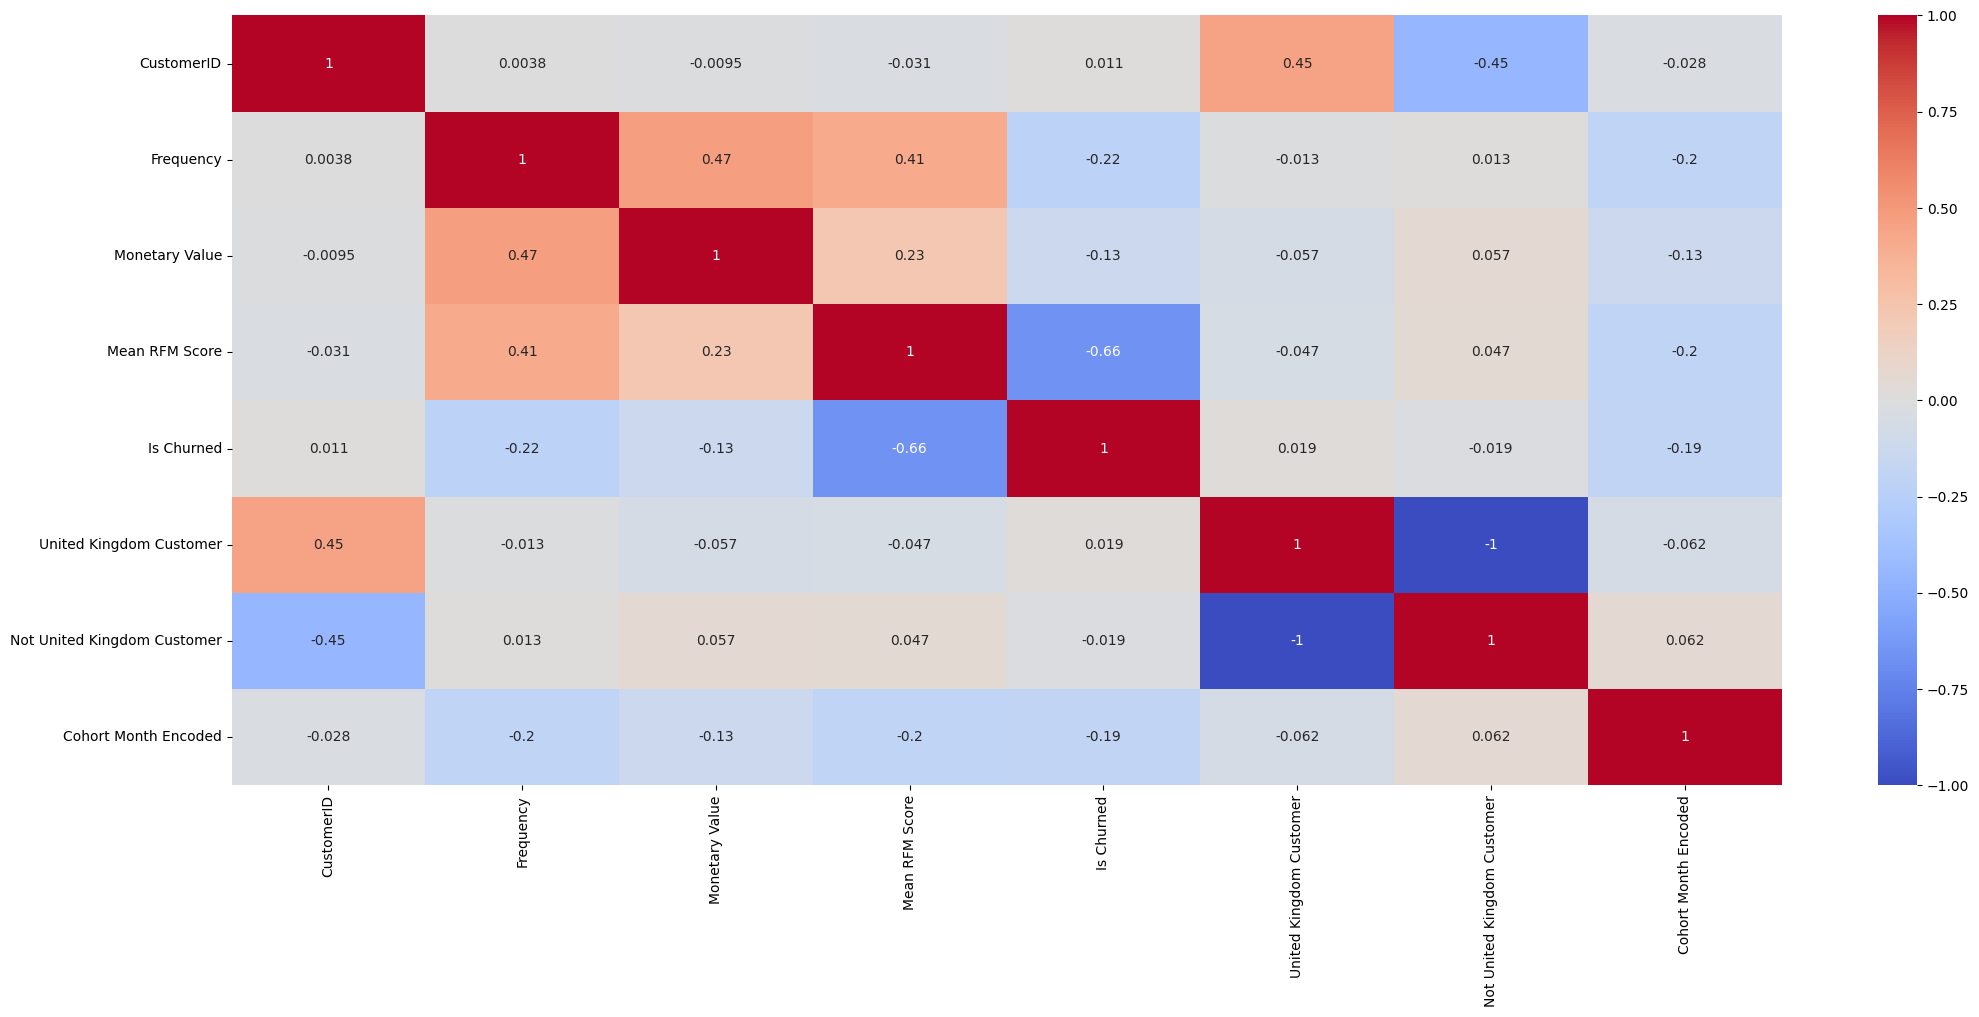

In [15]:
corr_matrix = modeling_df.corr(numeric_only = True)

plt.figure(figsize=(25,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

The correlation between frequency/monetary value/encoded cohort month and churn status is not strong. The relationship between Mean RFM Score and Is Churned is much stronger, though this may be largely because it is a third based on recency, the metric used to create the Is Churned value.

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [17]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(0.8562925170068028, 0.856565758833654)

In [18]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_pred)


(0.9226190476190477, 0.9226992001619924)

The values are way too high. I want to retry without RFM Score to see if it gives an actually resonable value.

In [19]:
modified_modeling_df = modeling_df.drop("Mean RFM Score", axis=1)

In [20]:
X = modified_modeling_df.drop(['CustomerID',"Is Churned"], axis=1)
y = modified_modeling_df["Is Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

standard_scaler = StandardScaler()

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [21]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(0.7576530612244898, 0.7573250987141844)

In [22]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_pred)


(0.7695578231292517, 0.7696365293105194)

These numbers seem a lot more reasonable and provides a pretty good score for predicting churn. Now we can use Cross Validation across multiple models to see if we can figure out which model is the best on to use.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
min_max_sc = MinMaxScaler()
make_interactions = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

In [24]:
cValExponents = np.linspace(2, -3, 6)
C_vals = np.array(float(10) ** cValExponents)
params = {'C':C_vals, 'l1_ratio':[0,0.5,1]}
LogReg = LogisticRegression(solver='saga', random_state=42, max_iter=10000)
Grid = GridSearchCV(LogReg, params, return_train_score=True)
scaler_CV_pipeline = Pipeline(steps=[('make_features', make_interactions), ('scaler',min_max_sc),('model', Grid)])
scaler_CV_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('make_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [25]:
y_train_predict_proba_LR_CV=scaler_CV_pipeline.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_LR_CV[:,1])

0.8327384140956408

best: LogisticRegression(C=np.float64(100.0), l1_ratio=1, max_iter=10000, random_state=42, solver='saga')

Decision Tree

In [26]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}
dt=tree.DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc', n_jobs=None, refit=True, cv=4, verbose=1, pre_dispatch=0,error_score=np.nan,return_train_score=True)
dt_cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

best: max depth = 6

In [27]:
y_train_predict_proba_dt=dt_cv.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_dt[:,1])

0.8968665395028305

Decision Trees are significantly better than Logistic Regression in less time, which is good to know. I'll now try to see if I can optimize the model using RandomizedSearchCV.

Params to optimize:
* n_estimators
* max_depth


I will create a range of 10 values for each of these values across a large range (1 versus 10^10) to figure out what gives the best values.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

value_exponents = [i for i in range(5)]
std_values = [10 ** i for i in value_exponents]

params_rf = {"n_estimators" : std_values, "max_depth" : [1, 2, 4, 6, 8, 10, 12]}

rf_cv = RandomForestClassifier()
rs_cv = RandomizedSearchCV(rf_cv, params_rf, scoring="roc_auc", error_score="raise")
search = rs_cv.fit(X,y)
search.best_params_

{'n_estimators': 1000, 'max_depth': 4}

Random Forest Best Params: {'n_estimators': 1000, 'max_depth': 4}

In [29]:
best_rf = RandomForestClassifier(n_estimators=1000, max_depth=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_rf.fit(X_train, y_train)
y_train_predict_proba=best_rf.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba[:,1])

0.8850004732516878

In [30]:
best_rf = RandomForestClassifier(n_estimators=1000, max_depth=6)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_rf.fit(X_train, y_train)
y_train_predict_proba=best_rf.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba[:,1])

0.9017872521972232

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_skf_score = cross_val_score(best_rf, X, y, cv=skf, scoring='roc_auc')
print(f"Random Forest Cross Validation ROC AUC mean: {np.mean(rf_skf_score)}, std: {np.std(rf_skf_score)}")

Random Forest Cross Validation ROC AUC mean: 0.8844444315986463, std: 0.007882353057280333


Interestingly, the "best_params" gave a worse result than the previous one with max_depth 6. I still believe max_depth 4 is likely the best one since the RandomizedSearchCV cross validated the result and the two models likely just ran into one of the train-test splits that was biased towards the max_depth of 6 rather than 4. Regardless, the accuracy score for the found model is good.

A cross validation mean roc auc score of around 88% and a standard deviation of around 0.7% means that the model is incredibly good.